In [37]:
import os

from dotenv import load_dotenv

load_dotenv()
from typing_extensions import Annotated

if os.environ["GOOGLE_API_KEY"]:
    print("GOOGLE_API_KEY is set")
else:
    raise ValueError("GOOGLE_API_KEY is not set")

GOOGLE_API_KEY is set


In [38]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite",
    temperature=1.0,  # Gemini 3.0+ defaults to 1.0
    max_tokens=None,
    timeout=None,
    max_retries=2,
    # other params...
)

## pydantic schema


In [39]:
from typing import TypedDict,List , Annotated

class graph_Schema(TypedDict):
    topic: str
    insta:str
    twitter:str
    linkedin:str


In [40]:
def create_post_insta(state: graph_Schema)->graph_Schema:

    #convert the model into dict
    # state=state.model_dump()

    #extract the topic from the state
    topic = state["topic"]

    #passing the topic to llm  to generate a linkedin post
    post = model.invoke(f"create an instagram post about {topic} and keep the tone casual and engaging")
    post = post.content[0]["text"]

    #updating the post with genrated post
    state["insta"] = post

    return {'insta': post}
    



def create_post_twitter(state: graph_Schema)->graph_Schema:

    #convert the model into dict
    

    #extract the topic from the state
    topic = state["topic"]

    #passing the topic to llm  to generate a linkedin post
    post = model.invoke(f"create an twitter post about {topic} and keep the tone quick")
    post = post.content[0]["text"]

    #updating the post with genrated post
    state["twitter"] = post

    return  {'twitter': post}

def create_post_linkedin(state: graph_Schema)->graph_Schema:

    #convert the model into dict
  

    #extract the topic from the state
    topic = state["topic"]

    #passing the topic to llm  to generate a linkedin post
    post = model.invoke(f"create an linkedin post about {topic} and keep the tone professional")
    post = post.content[0]["text"]

    #updating the post with genrated post
    state["linkedin"] = post

    return {'linkedin': post}
    





    







In [41]:
from langgraph.graph import StateGraph,START,END

graph = StateGraph(
    graph_Schema)

graph.add_node("create post insta",create_post_insta)
graph.add_node("create post twitter",create_post_twitter)
graph.add_node("create post linkedin",create_post_linkedin)


graph.add_edge(START,"create post twitter")
graph.add_edge(START,"create post insta")
graph.add_edge(START,"create post linkedin")

graph.add_edge("create post twitter",END)
graph.add_edge("create post insta",END)
graph.add_edge("create post linkedin",END)



pydantic_graph = graph.compile()

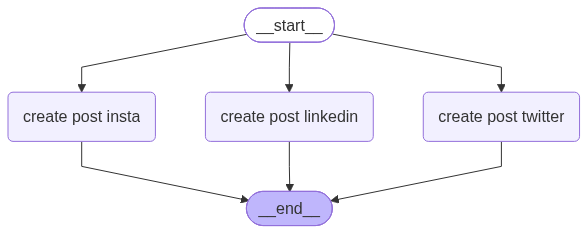

In [42]:
from IPython.display import display,Image

#you could see the error with the below command
Image(pydantic_graph.get_graph().draw_mermaid_png())

In [43]:
pydantic_graph.invoke(
    {"topic":"the importance of data privacy in the digital age",
     "insta":"",
     "twitter":"",
     "linkedin":""}
)

{'topic': 'the importance of data privacy in the digital age',
 'insta': 'Friendly reminder: your data is your digital footprint, and honestly? It deserves some personal space. 🛑👟✨\n\nThink about it—we lock our front doors, right? So why leave our digital lives wide open? Between the endless cookie pop-ups, targeted ads that somehow know what you were *just* thinking about, and endless scrolling, it’s easy to forget how much of *us* is out there on the internet. \n\nData privacy isn’t just for tech nerds or super-spies. It’s for anyone who wants to keep their personal business... well, *personal*. 🤫💻\n\nHere are 3 quick ways to protect your digital peace:\n1️⃣ **Check your app permissions:** Does that random flashlight app *really* need access to your location? Probs not. \n2️⃣ **Update your passwords:** Stop using "Password123" (we see you). Mix it up and use a password manager! \n3️⃣ **Enable 2FA:** Two-factor authentication is like a deadbolt for your accounts. Turn it on!\n\nLet’s 